In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

## Setup

### Utility Functions

In [2]:
def train(model: nn.Module, dataloader: DataLoader, nepochs:int = 100,) -> None:

    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

    loss_function = nn.CrossEntropyLoss()

    losses = []
    accuracies = []
    for epoch in tqdm(range(nepochs)):

        batch_losses, batch_accuracies = [], []
        for batch_idx, (features, labels) in enumerate(dataloader):

            optimizer.zero_grad()

            output = model.forward(features)

            loss = loss_function(output, labels)
            batch_losses.append(loss.item())

            loss.backward()

            optimizer.step()

            accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
            batch_accuracies.append(accuracy)

        losses.append(np.mean(batch_losses))
        accuracies.append(np.mean(batch_accuracies))

def test(model: nn.Module, dataloader: DataLoader) -> np.float32: 

    accuracies = []
    for batch_idx, (features, labels) in enumerate(dataloader):

        output = model(features)

        accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
        accuracies.append(accuracy)

    print(f'Accuracy = {np.mean(accuracies):.2f}')

    return np.mean(accuracies)

class utils:
    train = train
    test = test


### Load Data

In [3]:
url = 'https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv'
df = pd.read_csv(url)

# the data in the wine column are the labels
labels_orig = df['Wine'].values

# the data from all other columns are the features
features_orig = df.drop(columns='Wine').values

features_orig_tensor = torch.tensor(features_orig, dtype=torch.float32)
labels_orig_tensor = torch.tensor(labels_orig, dtype=torch.long)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


Take a look at the numbers in the columns titled `Nonflavonoid.phenols` and `Proline` in the table above. The numbers in the `Nonflavonoid.phenols` are smaller than one while the numbers in the `Proline` column are in the hundreds to one thousand.[<sup>1</sup>](#fn1) When passing the features from this data through a neural network, the data from `Proline` column are going to influence the model more than the data from the `Nonflavonoid.phenols` column, simply because they are bigger. That can negatively impact the performance of the model as the `Proline` data aren't necessarily more important just because the numbers are bigger. To avoid this issue, it's a good idea to make sure that the different features have the same scale, and we can do that through standardizing or normalizing the data. In this notebook, you'll learn different techniques for standardization and normalization. 

<span id="fn1"><sup>1</sup>It's true for the numbers that aren't displayed as well. You can plot them in a histogram to check if you want. </span>

## Section 1: Standardization and Normalization of Data Can Improve Network Performance 

| Code | Description |
| :-- | :-- |
| `utils.train(model, nepochs=100, dataloader=train_dataloader)` | Train model with utility function. |
| `accuracy = utils.test(model, dataloader=test_dataloader)` | Test model with utility function. |
| `(data - data.min())/(data.max()-data.min())` | Normalize data. |
| `(data - data.mean())/data.std()` | Standardize data against mean. |
| `(data - np.median(data))/data.std()` | Standardize data against median. |

**Example**: Normalize the `Proline` data, which is assigned to the variable `p` in the cell below. Assign the standardized values to a variable named n_proline and run the cell that plots a distribution of the `n_proline` to check that its lower bound is `0` and upper bound is `1`.

In [164]:
p = df['Proline'].values

n_proline = (p - p.min())/(p.max()-p.min())

Text(0, 0.5, 'Nr. of samples')

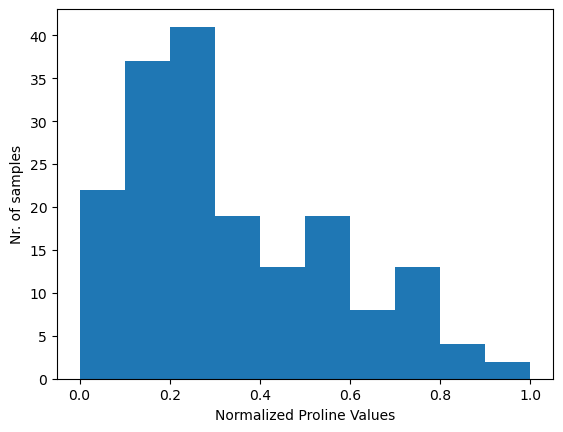

In [165]:
plt.hist(n_proline);
plt.xlabel('Normalized Proline Values')
plt.ylabel('Nr. of samples')

**Example**: Normalize the `Proline` data, which is assigned to the variable `p` in the cell below. Assign the standardized values to a variable named n_proline and run the cell that plots a distribution of the `n_proline` to check that 

In [ ]:
(features_orig_tensor-torch.mean(features_orig_tensor, dim=0))/torch.std(features_orig_tensor, dim=0)

tensor([[ 1.5143, -0.5607,  0.2314,  ...,  0.3612,  1.8427,  1.0102],
        [ 0.2456, -0.4980, -0.8257,  ...,  0.4049,  1.1103,  0.9625],
        [ 0.1963,  0.0212,  1.1062,  ...,  0.3174,  0.7864,  1.3912],
        ...,
        [ 0.3318,  1.7398, -0.3883,  ..., -1.6076, -1.4813,  0.2798],
        [ 0.2086,  0.2271,  0.0127,  ..., -1.5638, -1.3968,  0.2957],
        [ 1.3912,  1.5787,  1.3614,  ..., -1.5201, -1.4249, -0.5935]])

In [ ]:
features_scaled_tensor = torch.tensor(StandardScaler().fit_transform(features_orig), dtype=torch.float32)
features_scaled_tensor

tensor([[ 1.5186, -0.5622,  0.2321,  ...,  0.3622,  1.8479,  1.0130],
        [ 0.2463, -0.4994, -0.8280,  ...,  0.4061,  1.1134,  0.9652],
        [ 0.1969,  0.0212,  1.1093,  ...,  0.3183,  0.7886,  1.3951],
        ...,
        [ 0.3328,  1.7447, -0.3894,  ..., -1.6121, -1.4854,  0.2806],
        [ 0.2092,  0.2277,  0.0127,  ..., -1.5683, -1.4007,  0.2965],
        [ 1.3951,  1.5832,  1.3652,  ..., -1.5244, -1.4289, -0.5952]])

Set seed

In [4]:
SEED = 2025
generator = torch.Generator().manual_seed(SEED)
generator

In [5]:
dataset = TensorDataset(features_orig_tensor, labels_orig_tensor)
train_fraction = 0.8
test_fraction = 0.2

train_data, test_data = random_split(dataset, lengths=[train_fraction, test_fraction], generator=generator)

train_dataloader = DataLoader(train_data, batch_size=20, drop_last=True)

In [6]:
len(train_data)

143

In [7]:
class Model(nn.Module):
    def __init__(self,):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16,13)
        )

    def forward(self, x):
        output = self.layers(x)
        return output
    
Model()

Model(
  (layers): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=13, bias=True)
  )
)

Train without scaling

In [11]:
torch.manual_seed(SEED)
model = Model()

In [12]:
utils.train(model, nepochs=100, dataloader=train_dataloader)

100%|██████████| 100/100 [00:01<00:00, 53.77it/s]


Test

In [13]:
test_dataloader = DataLoader(test_data, batch_size=len(test_data))

In [14]:
accuracy_unscaled = test(model, dataloader=test_dataloader)

Accuracy = 0.77


With scaling

In [15]:
features_scaled_tensor = torch.tensor(MinMaxScaler().fit_transform(features_orig), dtype=torch.float32)

dataset = TensorDataset(features_scaled_tensor, labels_orig_tensor)
train_fraction = 0.8
test_fraction = 0.2

train_data, test_data = random_split(dataset, lengths=[train_fraction, test_fraction], generator=generator)

train_dataloader = DataLoader(train_data, batch_size=20, drop_last=True)

In [16]:
torch.manual_seed(SEED)
model = Model()

In [17]:
utils.train(model, nepochs=100, dataloader=train_dataloader)

100%|██████████| 100/100 [00:01<00:00, 53.70it/s]


Test

In [18]:
test_dataloader = DataLoader(test_data, batch_size=len(test_data))

In [19]:
accuracy_scaled = utils.test(model, dataloader=test_dataloader)

Accuracy = 1.00


## Section 2: Standardization Should be picked wisely

## Section 3: `sklearn.preprocessing` is super helpful

## Section 4: `sklearn.pipeline` wraps all this nicely